In [1]:
import torch
print(torch.cuda.is_available())

True


In [2]:
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 30.0 MB/s eta 0:00:0000:01


In [3]:
import os
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, classification_report
from ultralytics import YOLO

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [4]:
%%writefile data.yaml
path: /kaggle/input/datasets/eraianbudm/yolodataset/yolo_dataset
train: images/train
val: images/val
test: images/test

names:
  0: head
  1: nose
  2: body

Writing data.yaml


In [5]:
from ultralytics import YOLO

model = YOLO("yolo11s.pt")

model.train(
    data="data.yaml",
    epochs=200,
    imgsz=640,
    batch=16,
    patience=40,
    optimizer="AdamW",
    lr0=0.001,
    weight_decay=0.0005,
    device=0,
    name="posture_train"
)

Ultralytics 8.4.32 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla P100-PCIE-16GB, 16269MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=200, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=posture_train, nbs=64, nms=False, opset=None, optimize=False, optimizer=AdamW, overlap_mask=True, patience=40, perspective=0

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7ba6059c9be0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.04

In [6]:
import glob

print(glob.glob("/kaggle/working/runs/detect/posture_train/weights/*.pt"))

['/kaggle/working/runs/detect/posture_train/weights/best.pt', '/kaggle/working/runs/detect/posture_train/weights/last.pt']


In [7]:
import shutil

shutil.make_archive(
    "/kaggle/working/posture_model",
    'zip',
    "/kaggle/working/runs/detect/posture_train"
)


'/kaggle/working/posture_model.zip'

In [8]:
import shutil

shutil.copy(
    "/kaggle/working/runs/detect/posture_train/weights/best.pt",
    "/kaggle/working/best.pt"
)


'/kaggle/working/best.pt'

In [9]:
import os
print(os.listdir("/kaggle/working"))

['data.yaml', 'posture_model.zip', 'yolo11s.pt', '.virtual_documents', 'best.pt', 'yolo26n.pt', 'runs']


In [10]:
from ultralytics import YOLO

model = YOLO("best.pt")

results = model.predict(
    source="/kaggle/input/datasets/eraianbudm/newunrotated/unrotated_imagessss",
    conf=0.5,
    save=True,          # saves images
    save_txt=True       # saves txt labels (IMPORTANT)
)


WARNING ⚠️ 
Inference results will accumulate in RAM unless `stream=True` is passed, which can cause out-of-memory errors for large
sources or long-running streams and videos. See https://docs.ultralytics.com/modes/predict/ for help.

Example:
    results = model(source=..., stream=True)  # generator of Results objects
    for r in results:
        boxes = r.boxes  # Boxes object for bbox outputs
        masks = r.masks  # Masks object for segment masks outputs
        probs = r.probs  # Class probabilities for classification outputs

image 1/1099 /kaggle/input/datasets/eraianbudm/newunrotated/unrotated_imagessss/backward_lean_bad_posture-1-_jpg.rf.861f92207415d13fcca4f1b5013f9e10.jpg: 640x640 1 head, 1 nose, 1 body, 8.4ms
image 2/1099 /kaggle/input/datasets/eraianbudm/newunrotated/unrotated_imagessss/backward_lean_bad_posture-10-_jpg.rf.2b19a0b84e633f3edbafa026b2deede0.jpg: 640x640 1 head, 1 nose, 1 body, 8.2ms
image 3/1099 /kaggle/input/datasets/eraianbudm/newunrotated/unrotated_ima

In [11]:
import os
import numpy as np
import pandas as pd

label_path = "/kaggle/input/datasets/eraianbudm/newlabels/labels"

data = []

for file in os.listdir(label_path):
    if file.endswith(".txt"):

        head = None
        nose = None
        body = None

        filepath = os.path.join(label_path, file)

        with open(filepath, "r") as f:
            for line in f:
                parts = line.strip().split()
                class_id = int(parts[0])
                x = float(parts[1])
                y = float(parts[2])

                if class_id == 0:
                    head = (x, y)
                elif class_id == 1:
                    nose = (x, y)
                elif class_id == 2:
                    body = (x, y)

        if head and nose and body:

            angle_head_nose = np.degrees(
                np.arctan2(nose[1] - head[1], nose[0] - head[0])
            )

            angle_head_body = np.degrees(
                np.arctan2(body[1] - head[1], body[0] - head[0])
            )

            filename = file.lower()
            if "good" in filename:
                label = 0
            elif "forward" in filename:
                label = 1
            elif "backward" in filename:
                label = 2
            else:
                continue

            data.append([angle_head_nose, angle_head_body, label])

df = pd.DataFrame(
    data,
    columns=["angle_head_nose", "angle_head_body", "posture"]
)

print("Feature extraction complete")
print("Total samples:", len(df))
df.head()


Feature extraction complete
Total samples: 1071


,angle_head_nose,angle_head_body,posture
0,155.439135,98.800740,1
1,-169.607370,133.252139,2
2,170.812772,125.101472,2
3,143.206450,104.494208,1
4,12.321393,94.031074,1


In [12]:
import os
import numpy as np
import pandas as pd

# 🔹 Correct path to your label folder
label_path = "/kaggle/input/datasets/eraianbudm/newlabels/labels"

print("Total label files:", len(os.listdir(label_path)))

data = []

for file in os.listdir(label_path):
    if file.endswith(".txt"):

        head = None
        nose = None
        body = None

        filepath = os.path.join(label_path, file)

        with open(filepath, "r") as f:
            lines = f.readlines()

        for line in lines:
            parts = line.strip().split()

            if len(parts) != 5:
                continue

            class_id = int(parts[0])
            x = float(parts[1])
            y = float(parts[2])
            w = float(parts[3])
            h = float(parts[4])

            if class_id == 0:
                head = (x, y, w, h)

            elif class_id == 1:
                nose = (x, y, w, h)

            elif class_id == 2:
                body = (x, y, w, h)

        # Only keep if all detected
        if head is not None and nose is not None and body is not None:

            hx, hy, hw, hh = head
            nx, ny, nw, nh = nose
            bx, by, bw, bh = body

            # 🔹 Angle computation
            angle_head_nose = np.degrees(np.arctan2(ny - hy, nx - hx))
            angle_head_body = np.degrees(np.arctan2(by - hy, bx - hx))

            # 🔹 Label from filename
            fname = file.lower()

            if "good" in fname:
                label = 0
            elif "forward" in fname:
                label = 1
            elif "backward" in fname:
                label = 2
            else:
                continue

            data.append([
                hx, hy, hw, hh,
                nx, ny, nw, nh,
                bx, by, bw, bh,
                angle_head_nose,
                angle_head_body,
                label
            ])

columns = [
    "hx","hy","hw","hh",
    "nx","ny","nw","nh",
    "bx","by","bw","bh",
    "angle_head_nose",
    "angle_head_body",
    "label"
]

df = pd.DataFrame(data, columns=columns)

print("Feature extraction complete")
print("Total samples:", len(df))

df.head()

Total label files: 1098
Feature extraction complete
Total samples: 1071


,hx,hy,hw,hh,nx,ny,nw,nh,bx,by,bw,bh,angle_head_nose,angle_head_body,label
0,0.450237,0.254689,0.221627,0.207124,0.355541,0.297966,0.028387,0.036285,0.389765,0.645281,0.697275,0.574952,155.439135,98.800740,1
1,0.854414,0.207414,0.264534,0.138356,0.768455,0.191649,0.049072,0.032954,0.454902,0.632076,0.889480,0.735260,-169.607370,133.252139,2
2,0.604179,0.363810,0.209417,0.155778,0.514842,0.378259,0.029488,0.030316,0.354495,0.719055,0.708991,0.561223,170.812772,125.101472,2
3,0.534485,0.284936,0.177896,0.170005,0.482922,0.323501,0.037544,0.038292,0.441604,0.644230,0.725550,0.544055,143.206450,104.494208,1
4,0.661008,0.336176,0.188688,0.162431,0.745897,0.354718,0.024324,0.032660,0.634854,0.707303,0.543284,0.577448,12.321393,94.031074,1


In [13]:
import pandas as pd

df = pd.read_csv("/kaggle/input/datasets/eraianbudm/featuredata/Final_14_feature_dataset_all.csv")

print("Dataset loaded successfully")
print("Total samples:", len(df))
df.head()

Dataset loaded successfully
Total samples: 1071


,hx,hy,hw,hh,nx,ny,nw,nh,bx,by,bw,bh,angle_head_nose,angle_head_body,label
0,0.450237,0.254689,0.221627,0.207124,0.355541,0.297966,0.028387,0.036285,0.389765,0.645281,0.697275,0.574952,155.439135,98.800740,1
1,0.854414,0.207414,0.264534,0.138356,0.768455,0.191649,0.049072,0.032954,0.454902,0.632076,0.889480,0.735260,-169.607370,133.252139,2
2,0.604179,0.363810,0.209417,0.155778,0.514842,0.378259,0.029488,0.030316,0.354495,0.719055,0.708991,0.561223,170.812772,125.101472,2
3,0.534485,0.284936,0.177896,0.170005,0.482922,0.323501,0.037544,0.038292,0.441604,0.644230,0.725550,0.544055,143.206450,104.494208,1
4,0.661008,0.336176,0.188688,0.162431,0.745897,0.354718,0.024324,0.032660,0.634854,0.707303,0.543284,0.577448,12.321393,94.031074,1


In [14]:
X = df.drop("label", axis=1)
y = df["label"]

In [15]:
from sklearn.model_selection import train_test_split

# 70% train, 30% temp
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.30,
    stratify=y,
    random_state=42
)

# Split 30% into 20% val and 10% test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.33,   # 0.33 × 30% ≈ 10%
    stratify=y_temp,
    random_state=42
)

print("Train:", len(X_train))
print("Validation:", len(X_val))
print("Test:", len(X_test))

Train: 749
Validation: 215
Test: 107


In [16]:
print("Train distribution")
print(y_train.value_counts(normalize=True))

print("\nValidation distribution")
print(y_val.value_counts(normalize=True))

print("\nTest distribution")
print(y_test.value_counts(normalize=True))

Train distribution
label
0    0.487316
1    0.259012
2    0.253672
Name: proportion, dtype: float64

Validation distribution
label
0    0.488372
1    0.260465
2    0.251163
Name: proportion, dtype: float64

Test distribution
label
0    0.485981
1    0.261682
2    0.252336
Name: proportion, dtype: float64


In [17]:
train_df = df.loc[X_train.index]
val_df = df.loc[X_val.index]
test_df = df.loc[X_test.index]

print(train_df.head())

           hx        hy        hw        hh        nx        ny        nw  \
757  0.609978  0.294276  0.216165  0.167640  0.523387  0.311364  0.038940   
275  0.548300  0.336964  0.235652  0.176887  0.450314  0.348536  0.039200   
683  0.587165  0.386218  0.183468  0.154782  0.512852  0.405140  0.034662   
654  0.355455  0.257734  0.185280  0.160180  0.279688  0.284282  0.031544   
133  0.591452  0.312859  0.239111  0.178408  0.492291  0.325516  0.034220   

           nh        bx        by        bw        bh  angle_head_nose  \
757  0.030281  0.359798  0.645836  0.712934  0.536893       168.836603   
275  0.042269  0.441005  0.713391  0.644870  0.572307       173.264652   
683  0.035768  0.486398  0.730639  0.553270  0.532529       165.714586   
654  0.034501  0.436377  0.608983  0.462505  0.543091       160.690049   
133  0.035130  0.430101  0.700079  0.696668  0.597005       172.726047   

     angle_head_body  label  
757       125.436726      2  
275       105.909425      0  
68

In [18]:
train_df.to_csv("train_split.csv", index=False)
val_df.to_csv("val_split.csv", index=False)
test_df.to_csv("test_split.csv", index=False)

In [21]:
from sklearn.metrics import accuracy_score

def evaluate(model, name):
    print(f"\n{name}")
    print("Train Accuracy:",
          round(accuracy_score(y_train, model.predict(X_train))*100,2))
    print("Validation Accuracy:",
          round(accuracy_score(y_val, model.predict(X_val))*100,2))
    print("Test Accuracy:",
          round(accuracy_score(y_test, model.predict(X_test))*100,2))

In [22]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)

evaluate(dt, "Decision Tree")


Decision Tree
Train Accuracy: 100.0
Validation Accuracy: 89.3
Test Accuracy: 93.46


In [23]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=300,
    random_state=42
)

rf.fit(X_train, y_train)

evaluate(rf, "Random Forest")


Random Forest
Train Accuracy: 100.0
Validation Accuracy: 95.35
Test Accuracy: 97.2


In [24]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=5,
    random_state=42,
    eval_metric="mlogloss"
)

xgb.fit(X_train, y_train)

evaluate(xgb, "XGBoost")


XGBoost
Train Accuracy: 100.0
Validation Accuracy: 95.81
Test Accuracy: 98.13


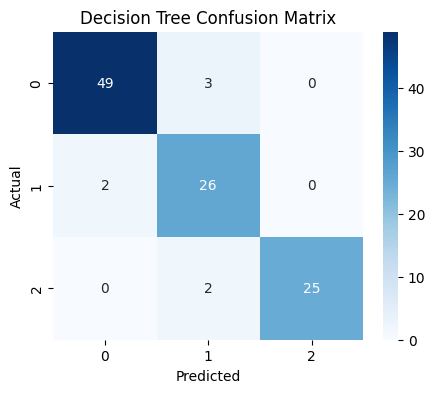

[[49  3  0]
 [ 2 26  0]
 [ 0  2 25]]


In [25]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm_dt = confusion_matrix(y_test, dt.predict(X_test))

plt.figure(figsize=(5,4))
sns.heatmap(cm_dt, annot=True, fmt="d", cmap="Blues")
plt.title("Decision Tree Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

print(cm_dt)

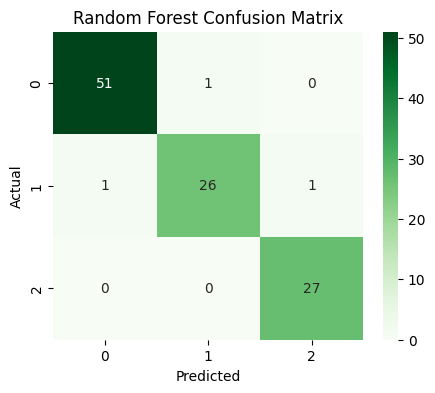

[[51  1  0]
 [ 1 26  1]
 [ 0  0 27]]


In [26]:
cm_rf = confusion_matrix(y_test, rf.predict(X_test))

plt.figure(figsize=(5,4))
sns.heatmap(cm_rf, annot=True, fmt="d", cmap="Greens")
plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

print(cm_rf)

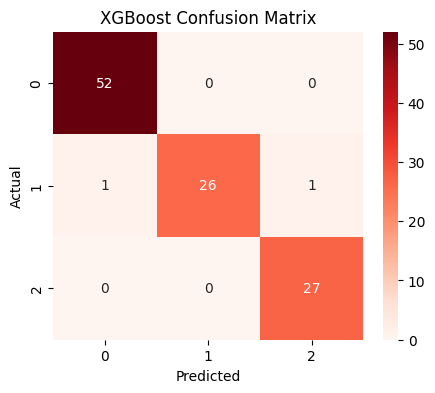

[[52  0  0]
 [ 1 26  1]
 [ 0  0 27]]


In [27]:
cm_xgb = confusion_matrix(y_test, xgb.predict(X_test))

plt.figure(figsize=(5,4))
sns.heatmap(cm_xgb, annot=True, fmt="d", cmap="Reds")
plt.title("XGBoost Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

print(cm_xgb)

In [28]:
X_angles = df[["angle_head_nose", "angle_head_body"]]
y = df["label"]

# Split again
X_train, X_temp, y_train, y_temp = train_test_split(
    X_angles, y, test_size=0.30, stratify=y, random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.33, stratify=y_temp, random_state=42
)

xgb_angles = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=5,
    random_state=42,
    eval_metric="mlogloss"
)

xgb_angles.fit(X_train, y_train)

print("Test Accuracy (Only Angles):",
      accuracy_score(y_test, xgb_angles.predict(X_test)))

Test Accuracy (Only Angles): 0.9626168224299065


In [29]:
X_bbox = df.drop(["angle_head_nose", "angle_head_body", "label"], axis=1)
y = df["label"]

# Split again
X_train, X_temp, y_train, y_temp = train_test_split(
    X_bbox, y, test_size=0.30, stratify=y, random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.33, stratify=y_temp, random_state=42
)

xgb_bbox = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=5,
    random_state=42,
    eval_metric="mlogloss"
)

xgb_bbox.fit(X_train, y_train)

print("Test Accuracy (Only BBox):",
      accuracy_score(y_test, xgb_bbox.predict(X_test)))

Test Accuracy (Only BBox): 0.9439252336448598
